In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.odr import ODR, Model, RealData
%run ./TbIG_Experiment_Functions.ipynb

In [2]:
data=pd.read_csv('NSR/2023_Mono_Temp_Corrected.csv', header=None)

In [3]:
temp = np.float64(data[0][0:50])
angle = np.float64(data[1][0:50])

temperror = np.float64(data[2][0:50])
angleerror=.00000001



<function matplotlib.pyplot.show(close=None, block=None)>

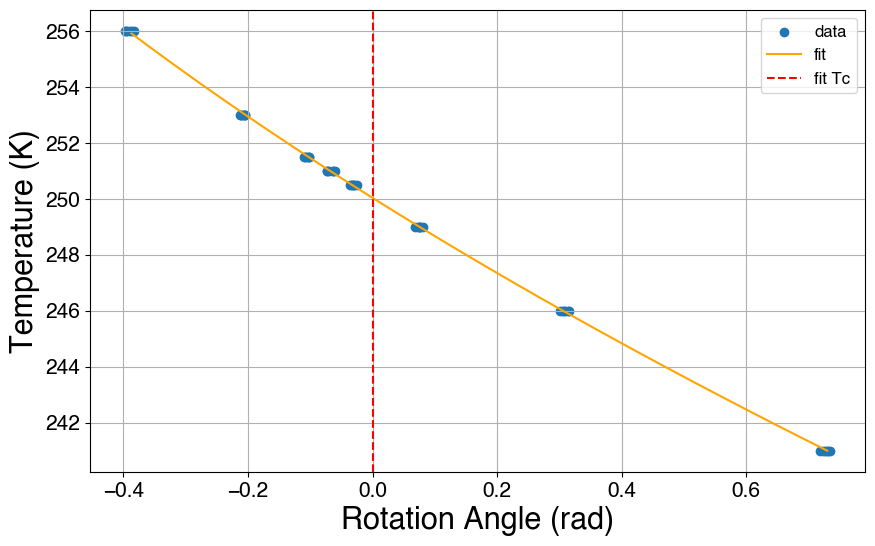

In [5]:
SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 15
huge=22

plt.rcParams.update({
    'font.size': MEDIUM_SIZE,
    'font.family': 'Helvetica',
    'axes.titlesize': huge,
    'axes.labelsize': huge,
    'xtick.labelsize': BIGGER_SIZE,
    'ytick.labelsize': BIGGER_SIZE,
    'legend.fontsize': MEDIUM_SIZE,
    'figure.titlesize': huge
})

# Define plot space
fig, ax = plt.subplots(figsize=(10, 6))


betas=[]

# Carry out Monte Carlo fitting analysis
x,y,sigma_x,sigma_y = temp, angle, temperror, angleerror
results=analysis(x, y, sigma_x, sigma_y)
comp=results[2]
delta=results[3]
beta=results[0]
betas.append(beta)

# Switching axes:
ax.scatter(y, x, label = 'data')
ax.errorbar(y, x, xerr=sigma_y, yerr=sigma_x, fmt='none')
newx=np.arange(min(x), max(x), .1)
plot,=ax.plot(beta[0]*newx**2+beta[1]*newx+beta[2],newx,label = 'fit', color= "Orange")

# Total uncertainty is (max-min)/2 divided by sqrt of sample number
# print(f"Total estimated T_comp: {np.round(np.mean(comps),2)} +/- {np.round(np.std(comps),2)}")

# Set plot title and axes labels
ax.set(ylabel = "Temperature (K)",
       xlabel = "Rotation Angle (rad)")

#title = "Monobeam Tc plot, corrected"

plt.axvline(0, color='red', linestyle='--',label = 'fit Tc')

ax.legend(loc='upper right')


#plt.text(.5,.9,f"Estimated T_comp: {np.round(results[2],2)} +/- {np.round(results[3],2)} K", transform=ax.transAxes)
#plt.text(.5,.8,f"Rotation Angle at 260 K: {np.round(beta[0]*260**2+beta[1]*260+beta[2],2)} rad", transform=ax.transAxes)
#plt.text(.5,.75,f"Rotation Angle at 240 K: {np.round(beta[0]*240**2+beta[1]*240+beta[2],2)} rad", transform=ax.transAxes)

ax.grid()

plt.savefig('Monobeam_Tcomp.png',dpi=200)

plt.show

In [27]:
plt.rcdefaults()
